# Training + Results for the Model

## Imports

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA

## Loading Data

In [2]:
DATA_PATH = Path("../final_data")
df = pd.read_csv(DATA_PATH / "model_ready_dataset.csv")
df.head()

,date,topic_Economy_taxes_tariffs_seed_binary,topic_Border_security_immigration_seed_binary,topic_Foreign_policy_seed_binary,topic_Energy_seed_binary,topic_Environment_seed_binary,topic_Government_reform_seed_binary,topic_Legal_battles_seed_binary,topic_Media_attacks_seed_binary,topic_Political_opposition_attacks_seed_binary,...,vix_close,delta_vix,vix_pct_change,vix_lag1,delta_vix_lag1,sp500_close,sp500_return,sp500_return_lag1,sp500_rolling_vol_5d,sp500_rolling_vol_10d
0,2025-05-27,1,1,1,0,1,1,1,1,1,...,18.96,-1.61,-0.078269,20.57,-1.72,5921.54,0.020459,-0.006708,0.013511,0.009668
1,2025-05-28,1,1,1,1,0,1,1,1,1,...,19.31,0.35,0.018460,18.96,-1.61,5888.55,-0.005571,0.020459,0.013611,0.009650
2,2025-05-30,1,1,1,1,0,1,0,1,1,...,18.57,-0.61,-0.031804,19.18,-0.13,5911.69,-0.000081,0.004011,0.010970,0.009639
3,2025-06-04,0,1,1,0,0,0,0,0,1,...,17.61,-0.08,-0.004522,17.69,-0.67,5970.81,0.000074,0.005800,0.002641,0.009538
4,2025-06-05,1,1,1,0,1,1,1,1,1,...,18.48,0.87,0.049404,17.61,-0.08,5939.30,-0.005277,0.000074,0.004303,0.007905


### Detailed Column Descriptions

In [3]:
summary = df.describe()
for col in summary.columns:
    print("{\n\tColumn: " + col + ",")
    print("\t" + str(df[col].dtype) + ",")
    print("\t" + str(summary[col][["mean","std","min","max"]]))
    print("}")

{
	Column: topic_Economy_taxes_tariffs_seed_binary,
	int64,
	mean    0.945355
std     0.227909
min     0.000000
max     1.000000
Name: topic_Economy_taxes_tariffs_seed_binary, dtype: float64
}
{
	Column: topic_Border_security_immigration_seed_binary,
	int64,
	mean    0.890710
std     0.312858
min     0.000000
max     1.000000
Name: topic_Border_security_immigration_seed_binary, dtype: float64
}
{
	Column: topic_Foreign_policy_seed_binary,
	int64,
	mean    0.972678
std     0.163468
min     0.000000
max     1.000000
Name: topic_Foreign_policy_seed_binary, dtype: float64
}
{
	Column: topic_Energy_seed_binary,
	int64,
	mean    0.814208
std     0.390006
min     0.000000
max     1.000000
Name: topic_Energy_seed_binary, dtype: float64
}
{
	Column: topic_Environment_seed_binary,
	int64,
	mean    0.606557
std     0.489854
min     0.000000
max     1.000000
Name: topic_Environment_seed_binary, dtype: float64
}
{
	Column: topic_Government_reform_seed_binary,
	int64,
	mean    0.874317
std     0.332

### Feature Setup and Selection

In [4]:
modeling_df = df.copy()

modeling_df["date"] = pd.to_datetime(modeling_df["date"])
modeling_df = modeling_df.sort_values("date").reset_index(drop=True)
modeling_df["abs_delta_vix"] = modeling_df["delta_vix"].apply(np.abs)

# response (Emission) variable
# we use absolute value to get the intensity instead of direction
y_col = "abs_delta_vix"

# nl features
seed_count_cols = [c for c in modeling_df.columns if c.startswith("topic_") and c.endswith("_seed_count")]
seed_binary_cols = [c for c in modeling_df.columns if c.startswith("topic_") and c.endswith("_seed_binary")]
sentence_count_cols = [c for c in modeling_df.columns if c.endswith("_topic_sentence_count")]
nmf_score_cols = [c for c in modeling_df.columns if c.startswith("nmf_topic_") and c.endswith("_score")]
nmf_binary_cols = [c for c in modeling_df.columns if c.startswith("nmf_topic_") and c.endswith("_binary")]
embedding_binary_cols = [c for c in modeling_df.columns if c.startswith("embedding_topic_") and c.endswith("_binary")]

financial_control_cols = [
    "vix_lag1",
    "delta_vix_lag1",
    "sp500_return",
    "sp500_return_lag1",
    "sp500_rolling_vol_5d",
    "sp500_rolling_vol_10d",
]

financial_control_cols = [c for c in financial_control_cols if c in modeling_df.columns]

In [5]:
# using nmf scores because they sum to 1 in each row. Using probabilities is better than raw counts or binary
nlp_cols = nmf_score_cols
# for the nlp-only model
X_nlp_cols = nlp_cols
# for the robustness check model
X_full_cols = X_nlp_cols + financial_control_cols

print("NLP columns:", X_nlp_cols)
print("Financial controls:", financial_control_cols)

NLP columns: ['nmf_topic_0_score', 'nmf_topic_1_score', 'nmf_topic_2_score', 'nmf_topic_3_score', 'nmf_topic_4_score', 'nmf_topic_5_score', 'nmf_topic_6_score', 'nmf_topic_7_score', 'nmf_topic_8_score', 'nmf_topic_9_score', 'nmf_topic_10_score']
Financial controls: ['vix_lag1', 'delta_vix_lag1', 'sp500_return', 'sp500_return_lag1', 'sp500_rolling_vol_5d', 'sp500_rolling_vol_10d']


In [6]:
def make_model_arrays(data, y_col, x_cols):
    keep_cols = [y_col] + x_cols
    d = data[keep_cols].copy()
    d = d.replace([np.inf, -np.inf], np.nan)
    d = d.dropna(subset=[y_col]).reset_index(drop=True)

    y = d[y_col].to_numpy().astype(float)
    X_raw = d[x_cols].to_numpy().astype(float)

    # impute nans with the mean then z-scale
    x_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    X = x_pipe.fit_transform(X_raw)

    return d, y, X, x_pipe

d_nlp, y, X_nlp, x_pipe_nlp = make_model_arrays(modeling_df, y_col, X_nlp_cols)
d_full, y_full, X_full, x_pipe_full = make_model_arrays(modeling_df, y_col, X_full_cols)

print(y.shape, X_nlp.shape)
print(y_full.shape, X_full.shape)

(183,) (183, 11)
(183,) (183, 17)


## Modeling

Below is just initialization of the HMM using the observed data to infer what the hidden regimes are given there are 3 states and the observed changes in VIX.

In [7]:
from hmmlearn.hmm import GaussianHMM

K = 3

hmm = GaussianHMM(
    n_components=K,
    covariance_type="diag",
    n_iter=1000,
    random_state=42,
    verbose=False
)

Y = y.reshape(-1, 1)
hmm.fit(Y)

hidden_states = hmm.predict(Y)
state_probs = hmm.predict_proba(Y)

baseline_hmm_df = d_nlp.copy()
baseline_hmm_df["latent_state"] = hidden_states

# sort states by learned mean delta_vix so labels are interpretable
state_means = pd.Series(hmm.means_.flatten()).sort_values()
state_order = state_means.index.tolist()
state_label_map = {
    old_state: new_label
    for new_label, old_state in enumerate(state_order)
}

baseline_hmm_df["ordered_state"] = baseline_hmm_df["latent_state"].map(state_label_map)

print("Learned emission means:")
print(hmm.means_.flatten())

print("Learned transition matrix:")
print(hmm.transmat_)

baseline_hmm_df.groupby("ordered_state")[y_col].agg(["count", "mean", "std", "min", "max"])

Learned emission means:
[0.18551587 0.76584238 2.35001744]
Learned transition matrix:
[[0.35526144 0.55638942 0.08834913]
 [0.25791199 0.59265305 0.14943497]
 [0.03817973 0.27836773 0.68345255]]


,count,mean,std,min,max
ordered_state,,,,,
0,45,0.175111,0.094739,0.00,0.34
1,90,0.830444,0.328411,0.33,1.71
2,48,2.482292,1.333570,0.10,5.74


### NLP Only

From the inferred latent states that the HMM gave us based on VIX data, we now use Logistic Classification to see if our predictor variables explain the latent states. A traditional HMM cannot talk about causality. But it can uncover regimes and states then we do the other work.

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

transition_df = baseline_hmm_df.copy()
transition_df["state_t"] = transition_df["ordered_state"]
transition_df["state_t_plus_1"] = transition_df["ordered_state"].shift(-1)

transition_df = transition_df.iloc[:-1].copy()
transition_df["state_t_plus_1"] = transition_df["state_t_plus_1"].astype(int)

_, _, X_trans, trans_pipe = make_model_arrays(
    modeling_df.iloc[:len(transition_df)].copy(),
    y_col,
    X_nlp_cols
)

# current inferred state as categorical information
state_dummies = pd.get_dummies(transition_df["state_t"], prefix="state").to_numpy()

X_transition = np.column_stack([state_dummies, X_trans])
y_transition = transition_df["state_t_plus_1"].to_numpy()

clf = LogisticRegression(
    max_iter=5000,
    class_weight="balanced"
)

clf.fit(X_transition, y_transition)

pred = clf.predict(X_transition)
print(classification_report(y_transition, pred))
print(confusion_matrix(y_transition, pred))

              precision    recall  f1-score   support

           0       0.37      0.56      0.44        45
           1       0.65      0.47      0.55        89
           2       0.76      0.77      0.76        48

    accuracy                           0.57       182
   macro avg       0.59      0.60      0.58       182
weighted avg       0.61      0.57      0.58       182

[[25 19  1]
 [36 42 11]
 [ 7  4 37]]


Coefficients of LogisticRegression Results

In [9]:
feature_names = (
    [f"current_state_{i}" for i in sorted(transition_df["state_t"].unique())]
    + X_nlp_cols
)

coef_df = pd.DataFrame(
    clf.coef_,
    columns=feature_names,
    index=[f"next_state_{i}" for i in clf.classes_]
)

coef_df.T.sort_values("next_state_2", ascending=False).head(20)

,next_state_0,next_state_1,next_state_2
current_state_2,-1.189452,-0.384507,1.573959
nmf_topic_9_score,-0.271482,0.043289,0.228193
nmf_topic_7_score,-0.088697,-0.100295,0.188992
nmf_topic_4_score,-0.130771,-0.035808,0.166580
nmf_topic_0_score,0.050146,-0.216166,0.166020
nmf_topic_5_score,-0.150312,-0.013681,0.163993
nmf_topic_1_score,-0.036196,-0.102658,0.138854
nmf_topic_6_score,0.018311,-0.090576,0.072265
nmf_topic_2_score,-0.114249,0.055367,0.058882
nmf_topic_10_score,-0.080509,0.025744,0.054765


### Robustness Checks (NLP + Financial)

In [10]:
_, _, X_trans_full, trans_pipe_full = make_model_arrays(
    modeling_df.iloc[:len(transition_df)].copy(),
    y_col,
    X_full_cols
)

X_transition_full = np.column_stack([state_dummies, X_trans_full])

clf_full = LogisticRegression(
    max_iter=5000,
    class_weight="balanced"
)

clf_full.fit(X_transition_full, y_transition)

feature_names_full = (
    [f"current_state_{i}" for i in sorted(transition_df["state_t"].unique())]
    + X_full_cols
)

coef_full_df = pd.DataFrame(
    clf_full.coef_,
    columns=feature_names_full,
    index=[f"next_state_{i}" for i in clf_full.classes_]
)

coef_full_df.T.sort_values("next_state_2", ascending=False).head(20)

,next_state_0,next_state_1,next_state_2
current_state_2,-0.914866,-0.214985,1.129851
vix_lag1,-0.853475,-0.193275,1.046751
delta_vix_lag1,-0.073780,-0.129949,0.203729
sp500_rolling_vol_5d,0.088403,-0.216260,0.127857
nmf_topic_7_score,0.044274,-0.073418,0.029144
nmf_topic_9_score,-0.109578,0.085921,0.023657
nmf_topic_0_score,0.174745,-0.175750,0.001005
nmf_topic_5_score,-0.024171,0.027845,-0.003674
nmf_topic_6_score,0.140169,-0.109697,-0.030472
nmf_topic_2_score,-0.028367,0.081377,-0.053010


In [11]:
pred = clf_full.predict(X_transition_full)
print(classification_report(y_transition, pred))
print(confusion_matrix(y_transition, pred))

              precision    recall  f1-score   support

           0       0.44      0.64      0.52        45
           1       0.70      0.54      0.61        89
           2       0.83      0.81      0.82        48

    accuracy                           0.64       182
   macro avg       0.65      0.67      0.65       182
weighted avg       0.67      0.64      0.64       182

[[29 15  1]
 [34 48  7]
 [ 3  6 39]]


### Model Comparisons

Examining transitions to one state at a time. (High then medium then low)

In [12]:
target_state = "next_state_2"

comparison = pd.DataFrame({
    "nlp_only_coef": coef_df.loc[target_state].reindex(feature_names),
    "with_controls_coef": coef_full_df.loc[target_state].reindex(feature_names)
})

comparison = comparison.dropna()
comparison.loc[X_nlp_cols].sort_values("nlp_only_coef", ascending=False)

,nlp_only_coef,with_controls_coef
nmf_topic_9_score,0.228193,0.023657
nmf_topic_7_score,0.188992,0.029144
nmf_topic_4_score,0.166580,-0.070757
nmf_topic_0_score,0.166020,0.001005
nmf_topic_5_score,0.163993,-0.003674
nmf_topic_1_score,0.138854,-0.213666
nmf_topic_6_score,0.072265,-0.030472
nmf_topic_2_score,0.058882,-0.053010
nmf_topic_10_score,0.054765,-0.070527
nmf_topic_8_score,0.007637,-0.084841


In [13]:
target_state = "next_state_1"

comparison = pd.DataFrame({
    "nlp_only_coef": coef_df.loc[target_state].reindex(feature_names),
    "with_controls_coef": coef_full_df.loc[target_state].reindex(feature_names)
})

comparison = comparison.dropna()
comparison.loc[X_nlp_cols].sort_values("nlp_only_coef", ascending=False)

,nlp_only_coef,with_controls_coef
nmf_topic_2_score,0.055367,0.081377
nmf_topic_9_score,0.043289,0.085921
nmf_topic_10_score,0.025744,0.060347
nmf_topic_8_score,0.012682,-0.020042
nmf_topic_5_score,-0.013681,0.027845
nmf_topic_3_score,-0.023182,-0.047060
nmf_topic_4_score,-0.035808,0.019731
nmf_topic_6_score,-0.090576,-0.109697
nmf_topic_7_score,-0.100295,-0.073418
nmf_topic_1_score,-0.102658,0.003721


In [14]:
target_state = "next_state_0"

comparison = pd.DataFrame({
    "nlp_only_coef": coef_df.loc[target_state].reindex(feature_names),
    "with_controls_coef": coef_full_df.loc[target_state].reindex(feature_names)
})

comparison = comparison.dropna()
comparison.loc[X_nlp_cols].sort_values("nlp_only_coef", ascending=False)

,nlp_only_coef,with_controls_coef
nmf_topic_0_score,0.050146,0.174745
nmf_topic_3_score,0.030156,0.106265
nmf_topic_6_score,0.018311,0.140169
nmf_topic_8_score,-0.020319,0.104883
nmf_topic_1_score,-0.036196,0.209945
nmf_topic_10_score,-0.080509,0.010180
nmf_topic_7_score,-0.088697,0.044274
nmf_topic_2_score,-0.114249,-0.028367
nmf_topic_4_score,-0.130771,0.051027
nmf_topic_5_score,-0.150312,-0.024171


## Interpretation

### Setup

In [15]:
state_summary_cols = [
    c for c in [
        "abs_delta_vix",
        "vix_close",
        "vix_pct_change",
        "sp500_return",
        "sp500_rolling_vol_5d",
        "sp500_rolling_vol_10d"
    ]
    if c in baseline_hmm_df.columns
]

state_summary = (
    baseline_hmm_df
    .groupby("ordered_state")[state_summary_cols]
    .agg(["count", "mean", "std", "min", "max"])
)

state_summary

abs_delta_vix                                
                      count      mean       std   min   max
ordered_state                                              
0                        45  0.175111  0.094739  0.00  0.34
1                        90  0.830444  0.328411  0.33  1.71
2                        48  2.482292  1.333570  0.10  5.74

Map int to label

In [16]:
state_name_map = {
    0: "Low volatility",
    1: "Medium volatility",
    2: "High volatility",
}

baseline_hmm_df["state_label"] = baseline_hmm_df["ordered_state"].map(state_name_map)

baseline_hmm_df[["ordered_state", "state_label"]].drop_duplicates().sort_values("ordered_state")

,ordered_state,state_label
3,0,Low volatility
0,1,Medium volatility
10,2,High volatility


### Plots

In [17]:
import matplotlib.pyplot as plt

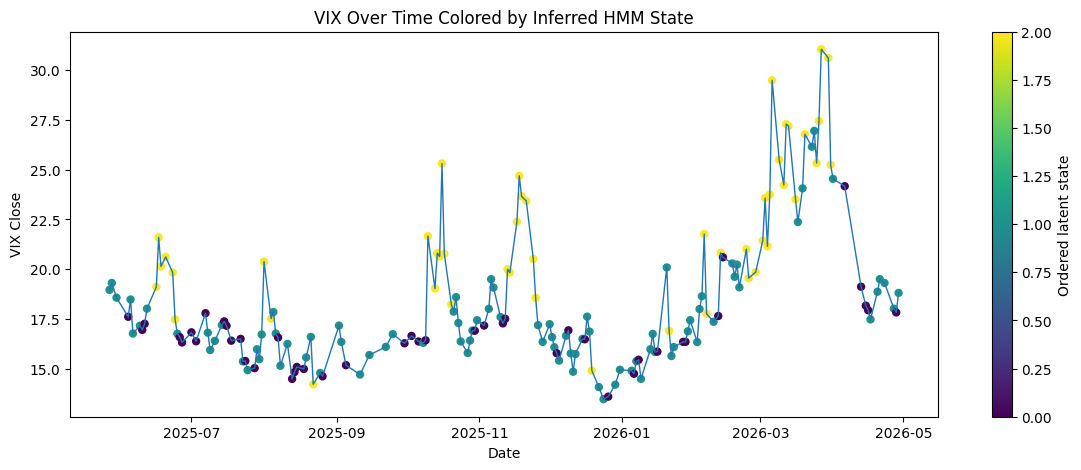

In [18]:
baseline_hmm_df["date"] = modeling_df["date"]
baseline_hmm_df["vix_close"] = modeling_df["vix_close"]

if "date" in baseline_hmm_df.columns and "vix_close" in baseline_hmm_df.columns:
    plt.figure(figsize=(14, 5))
    plt.plot(baseline_hmm_df["date"], baseline_hmm_df["vix_close"], linewidth=1)
    plt.scatter(
        baseline_hmm_df["date"],
        baseline_hmm_df["vix_close"],
        c=baseline_hmm_df["ordered_state"],
        s=25
    )
    plt.title("VIX Over Time Colored by Inferred HMM State")
    plt.xlabel("Date")
    plt.ylabel("VIX Close")
    plt.colorbar(label="Ordered latent state")
    plt.savefig("assets/vix_over_time_w_state.png", dpi=300)
    plt.show()

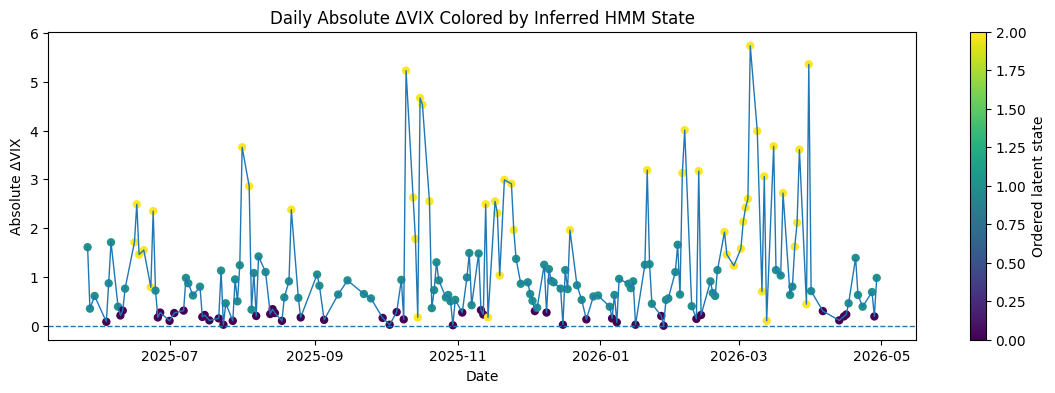

In [19]:
if "date" in baseline_hmm_df.columns:
    plt.figure(figsize=(14, 4))
    plt.plot(baseline_hmm_df["date"], baseline_hmm_df["abs_delta_vix"], linewidth=1)
    plt.scatter(
        baseline_hmm_df["date"],
        baseline_hmm_df["abs_delta_vix"],
        c=baseline_hmm_df["ordered_state"],
        s=25
    )
    plt.axhline(0, linestyle="--", linewidth=1)
    plt.title("Daily Absolute ΔVIX Colored by Inferred HMM State")
    plt.xlabel("Date")
    plt.ylabel("Absolute ΔVIX")
    plt.colorbar(label="Ordered latent state")
    plt.show()

Transition Matrix

In [20]:
inverse_state_label_map = {v: k for k, v in state_label_map.items()}
try:
    ordered_transmat = hmm.transmat_[state_order][:, state_order]
except NameError:
    ordered_transmat = hmm.transmat_

transition_matrix_df = pd.DataFrame(
    ordered_transmat,
    index=[f"from_state_{i}" for i in range(ordered_transmat.shape[0])],
    columns=[f"to_state_{i}" for i in range(ordered_transmat.shape[1])]
)

transition_matrix_df

,to_state_0,to_state_1,to_state_2
from_state_0,0.355261,0.556389,0.088349
from_state_1,0.257912,0.592653,0.149435
from_state_2,0.038180,0.278368,0.683453


### Interpret NLP Predictors

In [21]:
topic_mapping = {}
topics = [
    'Economy, taxes and tariffs', 
    'Border security and immigration', 
    'Foreign policy', 
    'Energy', 
    'Environment', 
    'Government reform', 
    'Legal battles', 
    'Media attacks', 
    'Political opposition attacks', 
    'Patriotism', 
    'Domestic and social initiatives'
    ]

topic_cols = [c for c in baseline_hmm_df.columns if c.startswith("nmf_topic") and c.endswith("_score")]
for c, t in zip(topic_cols, topics):
    topic_mapping[c] = t


def map_topics_from_columns(col: pd.Series):
    new_cols = []
    for val in col:
        new_cols.append(topic_mapping.get(val, val))
    
    return new_cols

In [22]:
topic_mapping

{'nmf_topic_0_score': 'Economy, taxes and tariffs',
 'nmf_topic_1_score': 'Border security and immigration',
 'nmf_topic_2_score': 'Foreign policy',
 'nmf_topic_3_score': 'Energy',
 'nmf_topic_4_score': 'Environment',
 'nmf_topic_5_score': 'Government reform',
 'nmf_topic_6_score': 'Legal battles',
 'nmf_topic_7_score': 'Media attacks',
 'nmf_topic_8_score': 'Political opposition attacks',
 'nmf_topic_9_score': 'Patriotism',
 'nmf_topic_10_score': 'Domestic and social initiatives'}

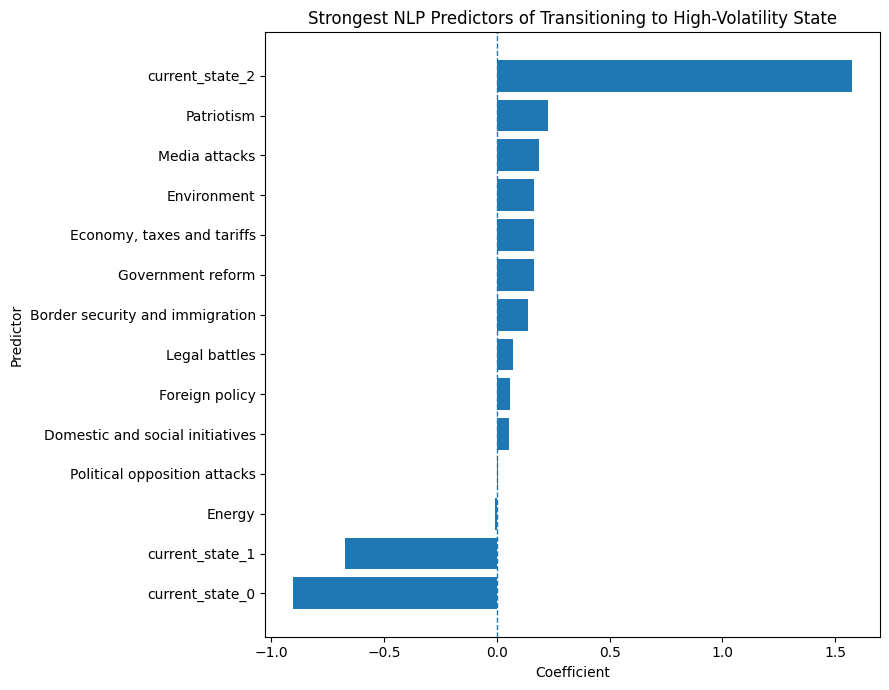

In [23]:
target_state = "next_state_2"

nlp_effects_high = (
    coef_df
    .loc[target_state]
    .sort_values(ascending=False)
    .to_frame("coef_to_high_state")
)

top_n = 10

plot_effects = pd.concat([
    nlp_effects_high.head(top_n),
    nlp_effects_high.tail(top_n)
]).sort_values("coef_to_high_state")

plt.figure(figsize=(9, 7))
plt.barh(map_topics_from_columns(plot_effects.index), plot_effects["coef_to_high_state"])
plt.axvline(0, linestyle="--", linewidth=1)
plt.title("Strongest NLP Predictors of Transitioning to High-Volatility State")
plt.xlabel("Coefficient")
plt.ylabel("Predictor")
plt.tight_layout()
plt.savefig("assets/high_volatility_predictors.png", dpi=300)
plt.show()

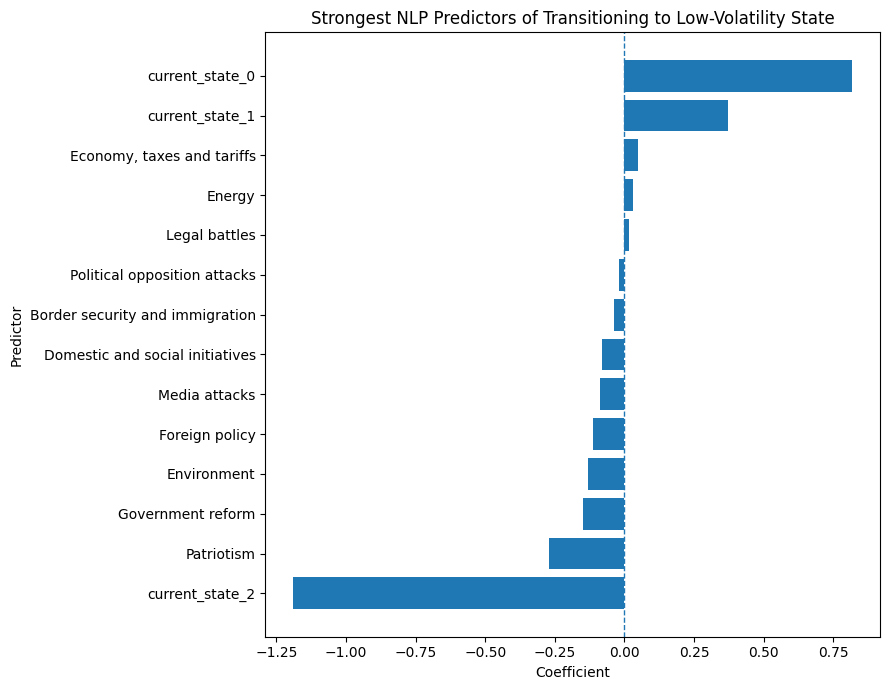

In [24]:
target_state = "next_state_0"

nlp_effects_high = (
    coef_df
    .loc[target_state]
    .sort_values(ascending=False)
    .to_frame("coef_to_low_state")
)

top_n = 10

plot_effects = pd.concat([
    nlp_effects_high.head(top_n),
    nlp_effects_high.tail(top_n)
]).sort_values("coef_to_low_state")

plt.figure(figsize=(9, 7))
plt.barh(map_topics_from_columns(plot_effects.index), plot_effects["coef_to_low_state"])
plt.axvline(0, linestyle="--", linewidth=1)
plt.title("Strongest NLP Predictors of Transitioning to Low-Volatility State")
plt.xlabel("Coefficient")
plt.ylabel("Predictor")
plt.tight_layout()
plt.savefig("assets/low_volatility_predictors.png", dpi=300)
plt.show()

### Compare Coefficient Values Pre/Post Financial Variables

In [25]:
if "coef_full_df" in globals():
    target_state = "next_state_2"

    common_features = coef_df.columns.intersection(coef_full_df.columns)

    coef_compare = pd.DataFrame({
        "nlp_only": coef_df.loc[target_state, common_features],
        "with_financial_controls": coef_full_df.loc[target_state, common_features],
    })

    coef_compare["difference"] = (
        coef_compare["with_financial_controls"] - coef_compare["nlp_only"]
    )

    coef_compare.sort_values("nlp_only", ascending=False).head(20)

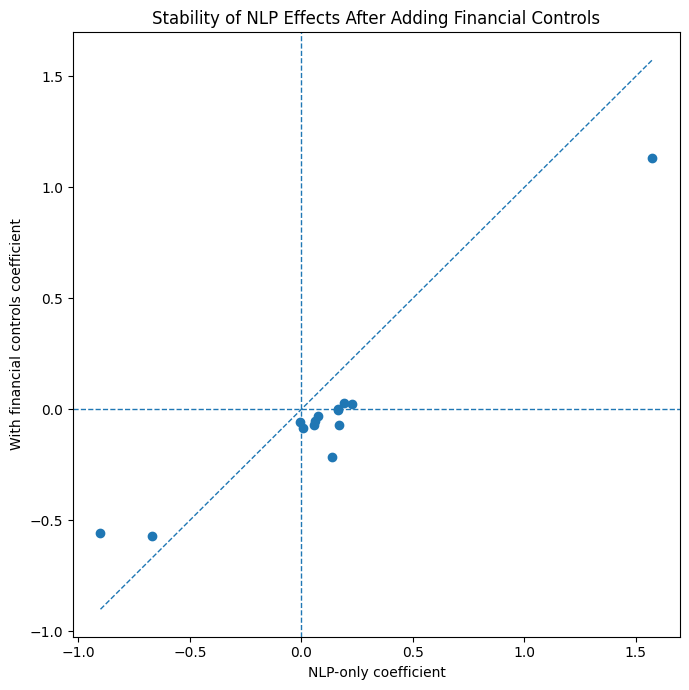

In [26]:
if "coef_full_df" in globals():
    plt.figure(figsize=(7, 7))
    plt.scatter(
        coef_compare["nlp_only"],
        coef_compare["with_financial_controls"]
    )
    plt.axhline(0, linestyle="--", linewidth=1)
    plt.axvline(0, linestyle="--", linewidth=1)
    plt.plot(
        [coef_compare.min().min(), coef_compare.max().max()],
        [coef_compare.min().min(), coef_compare.max().max()],
        linestyle="--",
        linewidth=1
    )
    plt.xlabel("NLP-only coefficient")
    plt.ylabel("With financial controls coefficient")
    plt.title("Stability of NLP Effects After Adding Financial Controls")
    plt.tight_layout()
    plt.savefig("assets/nlp_after_controls_stability_plot.png", dpi=300)
    plt.show()

In [27]:
high_state_days = (
    baseline_hmm_df[baseline_hmm_df["ordered_state"] == 0]
    .sort_values("abs_delta_vix", ascending=False)
)

display_cols = [
    c for c in [
        "date",
        "abs_delta_vix",
        "vix_close",
        "sp500_return",
        "state_label"
    ]
    if c in high_state_days.columns
]

high_state_days[display_cols].head(20)

,date,abs_delta_vix,vix_close,state_label
45,2025-08-14,0.34,14.83,Low volatility
86,2025-11-11,0.32,17.28,Low volatility
8,2025-06-11,0.31,17.26,Low volatility
21,2025-07-07,0.31,17.79,Low volatility
172,2026-04-06,0.30,24.17,Low volatility
101,2025-12-04,0.30,15.78,Low volatility
62,2025-10-06,0.28,16.37,Low volatility
104,2025-12-09,0.27,16.93,Low volatility
81,2025-11-03,0.27,17.17,Low volatility
18,2025-06-27,0.27,16.32,Low volatility


In [28]:
topic_state_summary = (
    baseline_hmm_df
    .groupby("ordered_state")[X_nlp_cols]
    .mean()
    .T
)

topic_state_summary.columns = [f"state_{c}" for c in topic_state_summary.columns]

# Difference between high-volatility state and low-volatility state
if "state_2" in topic_state_summary.columns and "state_0" in topic_state_summary.columns:
    topic_state_summary["high_minus_low"] = (
        topic_state_summary["state_2"] - topic_state_summary["state_0"]
    )

topic_state_summary.sort_values("high_minus_low", ascending=False).head(20)

,state_0,state_1,state_2,high_minus_low
nmf_topic_1_score,0.060529,0.052553,0.124650,0.064120
nmf_topic_7_score,0.063041,0.101403,0.121300,0.058259
nmf_topic_5_score,0.057158,0.063880,0.088820,0.031662
nmf_topic_10_score,0.094625,0.100174,0.081036,-0.013589
nmf_topic_2_score,0.090472,0.055759,0.074866,-0.015607
nmf_topic_4_score,0.073463,0.073233,0.055633,-0.017830
nmf_topic_6_score,0.095093,0.129494,0.071256,-0.023837
nmf_topic_3_score,0.108877,0.080796,0.082378,-0.026499
nmf_topic_8_score,0.115258,0.120753,0.083713,-0.031545
nmf_topic_0_score,0.113909,0.129051,0.080960,-0.032949


In [29]:
interpretation_rows = []

for state in sorted(baseline_hmm_df["ordered_state"].unique()):
    sub = baseline_hmm_df[baseline_hmm_df["ordered_state"] == state]
    interpretation_rows.append({
        "state": state,
        "label": state_name_map[state],
        "n_days": len(sub),
        "mean_abs_delta_vix": sub["abs_delta_vix"].mean(),
        "std_abs_delta_vix": sub["abs_delta_vix"].std(),
        "mean_vix": sub["vix_close"].mean() if "vix_close" in sub.columns else np.nan,
        "mean_sp500_return": sub["sp500_return"].mean() if "sp500_return" in sub.columns else np.nan,
    })

interpretation_table = pd.DataFrame(interpretation_rows)
interpretation_table

,state,label,n_days,mean_abs_delta_vix,std_abs_delta_vix,mean_vix,mean_sp500_return
0,0,Low volatility,45,0.175111,0.094739,16.688889,NaN
1,1,Medium volatility,90,0.830444,0.328411,17.338667,NaN
2,2,High volatility,48,2.482292,1.333570,22.012292,NaN


---